# 02 Multi-label feasibility audit

This notebook turns the existing patient-level NIH ChestX-ray14 splits into an audit-driven multi-label dataset.

It audits all 14 NIH pathology labels using predefined minimum-positive-count rules for training, validation, test, and Female/Male test subgroups.

The audit has two outputs:

- **Broad eligible set**: labels with adequate support for supplementary analysis.
- **Core multi-label set**: labels with stronger support for the main multi-label fairness experiment.

Only the core selected labels are saved to `multilabel_selected_labels.json`, so the later baseline and adversarial notebooks automatically train and evaluate the same focused set.

Run this notebook after `01_dataset_audit_fixed.ipynb`.


In [1]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

for folder in ["splits", "results", "checkpoints"]:
    os.makedirs(folder, exist_ok=True)

train_df = pd.read_csv("splits/train.csv")
val_df = pd.read_csv("splits/val.csv")
test_df = pd.read_csv("splits/test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


Train: (78873, 9)
Validation: (10953, 9)
Test: (22294, 9)


## 1. Define the NIH labels and convert `Finding Labels` to a multi-hot target matrix

`No Finding` is deliberately excluded because it is the absence of the 14 pathology labels, not an additional pathology class.


In [2]:
ALL_LABELS = [
    "Atelectasis",
    "Cardiomegaly",
    "Effusion",
    "Infiltration",
    "Mass",
    "Nodule",
    "Pneumonia",
    "Pneumothorax",
    "Consolidation",
    "Edema",
    "Emphysema",
    "Fibrosis",
    "Pleural_Thickening",
    "Hernia",
]

def make_multilabel_columns(split_df, labels=ALL_LABELS):
    split_df = split_df.copy()
    dummies = split_df["Finding Labels"].fillna("").str.get_dummies(sep="|")
    dummies = dummies.reindex(columns=labels, fill_value=0).astype(np.int64)

    for label in labels:
        split_df[f"label_{label}"] = dummies[label].to_numpy()

    return split_df, dummies

train_multi, train_targets = make_multilabel_columns(train_df)
val_multi, val_targets = make_multilabel_columns(val_df)
test_multi, test_targets = make_multilabel_columns(test_df)

print("Target matrix shapes:")
print("Train:", train_targets.shape)
print("Validation:", val_targets.shape)
print("Test:", test_targets.shape)

assert (train_targets.sum(axis=1) >= 0).all()


Target matrix shapes:
Train: (78873, 14)
Validation: (10953, 14)
Test: (22294, 14)


## 2. Audit criteria

The rules are stated before the final selection. They are designed to ensure that each included label has enough positive cases for stable per-label AUROC/AUPRC and Female/Male recall/FNR estimates.

Two levels are retained:

- **Broad eligibility** identifies labels with sufficient support for supplementary analyses.
- **Core selection** uses stricter support requirements and defines the labels for the main multi-label experiment.

The core set is intentionally more conservative because the dissertation will compare sex-specific, threshold-dependent metrics for each label.


In [3]:
BROAD_SELECTION_RULES = {
    # Adequate support for broad / supplementary multi-label analyses.
    "train_positive_min": 1500,
    "val_positive_min": 200,
    "test_positive_min": 400,
    "female_test_positive_min": 150,
    "male_test_positive_min": 150,
}

CORE_SELECTION_RULES = {
    # Stronger support for the main multi-label fairness experiment.
    "train_positive_min": 3000,
    "val_positive_min": 400,
    "test_positive_min": 900,
    "female_test_positive_min": 300,
    "male_test_positive_min": 300,
}

print("Broad eligibility rules:")
print(json.dumps(BROAD_SELECTION_RULES, indent=2))

print("\nCore selection rules:")
print(json.dumps(CORE_SELECTION_RULES, indent=2))


Broad eligibility rules:
{
  "train_positive_min": 1500,
  "val_positive_min": 200,
  "test_positive_min": 400,
  "female_test_positive_min": 150,
  "male_test_positive_min": 150
}

Core selection rules:
{
  "train_positive_min": 3000,
  "val_positive_min": 400,
  "test_positive_min": 900,
  "female_test_positive_min": 300,
  "male_test_positive_min": 300
}


In [4]:
def positive_counts_by_sex(split_df, target_matrix):
    out = {}
    for sex_value, sex_name in [(0, "female"), (1, "male")]:
        mask = split_df["sex"].to_numpy() == sex_value
        out[sex_name] = target_matrix.loc[mask].sum(axis=0)
    return out


def rule_failures(values, rules):
    failures = []

    if values["train_positive"] < rules["train_positive_min"]:
        failures.append("train positives below minimum")
    if values["val_positive"] < rules["val_positive_min"]:
        failures.append("validation positives below minimum")
    if values["test_positive"] < rules["test_positive_min"]:
        failures.append("test positives below minimum")
    if values["test_female_positive"] < rules["female_test_positive_min"]:
        failures.append("female test positives below minimum")
    if values["test_male_positive"] < rules["male_test_positive_min"]:
        failures.append("male test positives below minimum")

    return failures


train_by_sex = positive_counts_by_sex(train_multi, train_targets)
val_by_sex = positive_counts_by_sex(val_multi, val_targets)
test_by_sex = positive_counts_by_sex(test_multi, test_targets)

audit_rows = []

for label in ALL_LABELS:
    values = {
        "label": label,
        "train_positive": int(train_targets[label].sum()),
        "val_positive": int(val_targets[label].sum()),
        "test_positive": int(test_targets[label].sum()),
        "train_prevalence": float(train_targets[label].mean()),
        "val_prevalence": float(val_targets[label].mean()),
        "test_prevalence": float(test_targets[label].mean()),
        "train_female_positive": int(train_by_sex["female"][label]),
        "train_male_positive": int(train_by_sex["male"][label]),
        "val_female_positive": int(val_by_sex["female"][label]),
        "val_male_positive": int(val_by_sex["male"][label]),
        "test_female_positive": int(test_by_sex["female"][label]),
        "test_male_positive": int(test_by_sex["male"][label]),
    }

    broad_failures = rule_failures(values, BROAD_SELECTION_RULES)
    core_failures = rule_failures(values, CORE_SELECTION_RULES)

    values["broad_eligible"] = len(broad_failures) == 0
    values["broad_exclusion_reason"] = " | ".join(broad_failures) if broad_failures else ""

    values["core_selected"] = len(core_failures) == 0
    values["core_exclusion_reason"] = " | ".join(core_failures) if core_failures else ""

    audit_rows.append(values)

label_audit = pd.DataFrame(audit_rows)
label_audit = label_audit.sort_values(
    ["core_selected", "broad_eligible", "test_positive"],
    ascending=[False, False, False],
).reset_index(drop=True)

pd.set_option("display.max_colwidth", 250)
display(label_audit)


,label,train_positive,val_positive,test_positive,train_prevalence,val_prevalence,test_prevalence,train_female_positive,train_male_positive,val_female_positive,val_male_positive,test_female_positive,test_male_positive,broad_eligible,broad_exclusion_reason,core_selected,core_exclusion_reason
0,Infiltration,13868,1929,4097,0.175827,0.176116,0.183771,5925,7943,857,1072,1685,2412,True,,True,
1,Effusion,9533,1231,2553,0.120865,0.112389,0.114515,4220,5313,535,696,1127,1426,True,,True,
2,Atelectasis,8262,1090,2207,0.104751,0.099516,0.098995,3363,4899,442,648,848,1359,True,,True,
3,Nodule,4415,636,1280,0.055976,0.058066,0.057415,1754,2661,316,320,576,704,True,,True,
4,Mass,4199,507,1076,0.053237,0.046289,0.048264,1617,2582,213,294,423,653,True,,True,
5,Pneumothorax,3841,441,1020,0.048699,0.040263,0.045752,1837,2004,174,267,574,446,True,,True,
6,Consolidation,3280,436,951,0.041586,0.039806,0.042657,1392,1888,241,195,368,583,True,,True,
7,Pleural_Thickening,2424,301,660,0.030733,0.027481,0.029604,975,1449,109,192,259,401,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
8,Cardiomegaly,1863,295,618,0.023620,0.026933,0.027720,994,869,117,178,358,260,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | male test positives below minimum
9,Emphysema,1727,258,531,0.021896,0.023555,0.023818,641,1086,78,180,187,344,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum


In [5]:
broad_eligible_labels = label_audit.loc[
    label_audit["broad_eligible"], "label"
].tolist()

selected_labels = label_audit.loc[
    label_audit["core_selected"], "label"
].tolist()

broad_but_not_core = label_audit.loc[
    label_audit["broad_eligible"] & ~label_audit["core_selected"],
    ["label", "core_exclusion_reason"],
]

excluded_from_broad = label_audit.loc[
    ~label_audit["broad_eligible"],
    ["label", "broad_exclusion_reason"],
]

print("Broad eligible labels:", broad_eligible_labels)
print("Number of broad eligible labels:", len(broad_eligible_labels))

print("\nCore selected labels for the main multi-label experiment:", selected_labels)
print("Number of core selected labels:", len(selected_labels))

if len(selected_labels) < 2:
    raise RuntimeError(
        "Fewer than two labels passed the core selection rules. "
        "Review the thresholds before training."
    )

print("\nBroad-eligible labels not retained in the core set:")
display(broad_but_not_core)

print("\nExcluded from the broad set:")
display(excluded_from_broad)


Broad eligible labels: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation', 'Pleural_Thickening', 'Cardiomegaly', 'Emphysema', 'Edema']
Number of broad eligible labels: 11

Core selected labels for the main multi-label experiment: ['Infiltration', 'Effusion', 'Atelectasis', 'Nodule', 'Mass', 'Pneumothorax', 'Consolidation']
Number of core selected labels: 7

Broad-eligible labels not retained in the core set:


,label,core_exclusion_reason
7,Pleural_Thickening,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
8,Cardiomegaly,train positives below minimum | validation positives below minimum | test positives below minimum | male test positives below minimum
9,Emphysema,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
10,Edema,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum | male test positives below minimum



Excluded from the broad set:


,label,broad_exclusion_reason
11,Fibrosis,train positives below minimum | validation positives below minimum | test positives below minimum
12,Pneumonia,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
13,Hernia,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum | male test positives below minimum


## 3. Inspect co-occurrence among the core selected labels

Co-occurrence does not change the independent sigmoid outputs used by multi-label BCE, but it helps interpret the dataset and later results.

The co-occurrence matrix below is computed only for the core set used by the main experiment.


In [6]:
selected_train_targets = train_targets[selected_labels]

cooccurrence = selected_train_targets.T.dot(selected_train_targets)
cooccurrence.index.name = "label"
cooccurrence.columns.name = "label"

cooccurrence.to_csv("results/multilabel_train_label_cooccurrence.csv")
cooccurrence


label,Infiltration,Effusion,Atelectasis,Nodule,Mass,Pneumothorax,Consolidation
label,,,,,,,
Infiltration,13868,2881,2325,1084,817,672,820
Effusion,2881,9533,2384,646,924,696,881
Atelectasis,2325,2384,8262,416,548,562,871
Nodule,1084,646,416,4415,627,241,302
Mass,817,924,548,627,4199,340,452
Pneumothorax,672,696,562,241,340,3841,152
Consolidation,820,881,871,302,452,152,3280


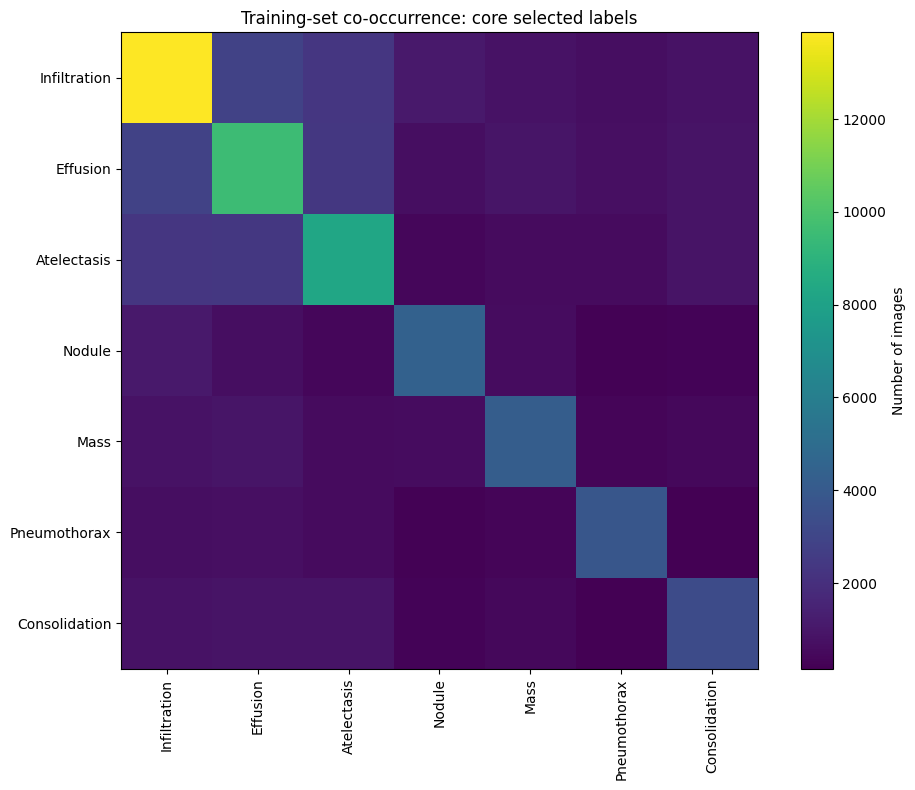

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(cooccurrence.to_numpy())
ax.set_xticks(range(len(selected_labels)))
ax.set_yticks(range(len(selected_labels)))
ax.set_xticklabels(selected_labels, rotation=90)
ax.set_yticklabels(selected_labels)
ax.set_title("Training-set co-occurrence: core selected labels")
fig.colorbar(image, ax=ax, label="Number of images")
plt.tight_layout()
plt.show()


## 4. Save the audit, core selected labels, and multi-label splits

The next notebooks load the JSON core label list and these saved split files. This prevents accidental label-list drift between the multi-label baseline and adversarial experiments.

The broad eligible list is also saved for supplementary analysis, but the downstream training notebooks use only the core selected set.


In [8]:
label_audit.to_csv("results/multilabel_label_audit.csv", index=False)

pd.DataFrame({"label": broad_eligible_labels}).to_csv(
    "results/multilabel_broad_eligible_labels.csv", index=False
)

pd.DataFrame({"label": selected_labels}).to_csv(
    "results/multilabel_selected_labels.csv", index=False
)

config = {
    # Backward-compatible key used by notebooks 07–09.
    "selected_labels": selected_labels,

    # Explicit documentation of the two-tier audit.
    "core_selected_labels": selected_labels,
    "broad_eligible_labels": broad_eligible_labels,
    "broad_selection_rules": BROAD_SELECTION_RULES,
    "core_selection_rules": CORE_SELECTION_RULES,
    "selection_note": (
        "All 14 NIH labels were audited using predefined sample-support criteria. "
        "The core selected labels meet stricter minimum positive-count requirements "
        "and are used for the main multi-label fairness experiment. "
        "Broad-eligible but non-core labels are retained for supplementary analysis."
    ),
}

with open("results/multilabel_selected_labels.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

label_columns = [f"label_{label}" for label in ALL_LABELS]
base_columns = [
    "Image Index",
    "image_path",
    "Finding Labels",
    "Patient ID",
    "Patient Age",
    "Patient Gender",
    "View Position",
    "sex",
]

save_columns = base_columns + label_columns

train_multi[save_columns].to_csv("splits/multilabel_train.csv", index=False)
val_multi[save_columns].to_csv("splits/multilabel_val.csv", index=False)
test_multi[save_columns].to_csv("splits/multilabel_test.csv", index=False)

print("Saved:")
for saved_path in [
    "results/multilabel_label_audit.csv",
    "results/multilabel_broad_eligible_labels.csv",
    "results/multilabel_selected_labels.csv",
    "results/multilabel_selected_labels.json",
    "results/multilabel_train_label_cooccurrence.csv",
    "splits/multilabel_train.csv",
    "splits/multilabel_val.csv",
    "splits/multilabel_test.csv",
]:
    print(" -", saved_path)


Saved:
 - results/multilabel_label_audit.csv
 - results/multilabel_broad_eligible_labels.csv
 - results/multilabel_selected_labels.csv
 - results/multilabel_selected_labels.json
 - results/multilabel_train_label_cooccurrence.csv
 - splits/multilabel_train.csv
 - splits/multilabel_val.csv
 - splits/multilabel_test.csv


In [9]:
print("Core selected labels for the main multi-label experiment:")
display(
    label_audit.loc[label_audit["core_selected"]]
    .sort_values("test_positive", ascending=False)
)

print("\nBroad-eligible labels retained only for supplementary analysis:")
display(
    label_audit.loc[
        label_audit["broad_eligible"] & ~label_audit["core_selected"]
    ].sort_values("test_positive", ascending=False)
)

print("\nBroad eligibility rules:")
print(json.dumps(BROAD_SELECTION_RULES, indent=2))

print("\nCore selection rules:")
print(json.dumps(CORE_SELECTION_RULES, indent=2))


Core selected labels for the main multi-label experiment:


,label,train_positive,val_positive,test_positive,train_prevalence,val_prevalence,test_prevalence,train_female_positive,train_male_positive,val_female_positive,val_male_positive,test_female_positive,test_male_positive,broad_eligible,broad_exclusion_reason,core_selected,core_exclusion_reason
0,Infiltration,13868,1929,4097,0.175827,0.176116,0.183771,5925,7943,857,1072,1685,2412,True,,True,
1,Effusion,9533,1231,2553,0.120865,0.112389,0.114515,4220,5313,535,696,1127,1426,True,,True,
2,Atelectasis,8262,1090,2207,0.104751,0.099516,0.098995,3363,4899,442,648,848,1359,True,,True,
3,Nodule,4415,636,1280,0.055976,0.058066,0.057415,1754,2661,316,320,576,704,True,,True,
4,Mass,4199,507,1076,0.053237,0.046289,0.048264,1617,2582,213,294,423,653,True,,True,
5,Pneumothorax,3841,441,1020,0.048699,0.040263,0.045752,1837,2004,174,267,574,446,True,,True,
6,Consolidation,3280,436,951,0.041586,0.039806,0.042657,1392,1888,241,195,368,583,True,,True,



Broad-eligible labels retained only for supplementary analysis:


,label,train_positive,val_positive,test_positive,train_prevalence,val_prevalence,test_prevalence,train_female_positive,train_male_positive,val_female_positive,val_male_positive,test_female_positive,test_male_positive,broad_eligible,broad_exclusion_reason,core_selected,core_exclusion_reason
7,Pleural_Thickening,2424,301,660,0.030733,0.027481,0.029604,975,1449,109,192,259,401,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
8,Cardiomegaly,1863,295,618,0.023620,0.026933,0.027720,994,869,117,178,358,260,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | male test positives below minimum
9,Emphysema,1727,258,531,0.021896,0.023555,0.023818,641,1086,78,180,187,344,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum
10,Edema,1639,210,454,0.020780,0.019173,0.020364,821,818,109,101,169,285,True,,False,train positives below minimum | validation positives below minimum | test positives below minimum | female test positives below minimum | male test positives below minimum



Broad eligibility rules:
{
  "train_positive_min": 1500,
  "val_positive_min": 200,
  "test_positive_min": 400,
  "female_test_positive_min": 150,
  "male_test_positive_min": 150
}

Core selection rules:
{
  "train_positive_min": 3000,
  "val_positive_min": 400,
  "test_positive_min": 900,
  "female_test_positive_min": 300,
  "male_test_positive_min": 300
}
